In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)

from src.utils import configure_logger

import pandas as pd
import matplotlib.pyplot as plt

from typing import Any 
from GNN.training.utils import collect_dataset_paths
from GNN.training.runners import MODEL_REGISTRY
from GNN.training.train_config import TrainConfig
from experiments.plotting import view_correlation

from collections.abc import Callable
Loader = Callable[..., Any]

In [3]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [4]:
import ast

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [5]:
def run(
    model_type,
    epochs,
    lr,
    loss_type,
    batch_size,
    training_mode,
    family,
    target,
    model_hparams,
    train_hparams,
    training_data_dir,
    model_save_path,
    plot_qubits=10,
    plot_layers=80,
):
    training(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        model_type=model_type,
        model_hparams=model_hparams,
        train_hparams=train_hparams,
        training_data_dir=training_data_dir,
        model_save_path=model_save_path,
        show_progress=True,
        show_val_progress=False,
        log_every_n_batches=10,
        heartbeat_secs=60.0,
        epoch_time_warning_secs=600.0,
    )
    training_scope = "family" if training_mode == "per_family" else "global"
    predictions(
        model_path=model_save_path,
        model_kind=model_type,
        training_scope=training_scope,
        loss_type=loss_type,
        model_family=family,
        dataset_root=training_data_dir,
        dataset_family=family,
        batch_size=batch_size,
        global_feature_variant="binned",
        node_feature_backend_variant=None,
        plot_n_layers=plot_layers,
        plot_n_qubits=plot_qubits,
        split_by_family=True,
        show_progress=True,
    )

    df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
    cols_to_fix = ["n_qubits", "n_layers", "seed"]

    for col in cols_to_fix:
        df[col] = df[col].apply(to_scalar).astype(int)
    view_correlation(
        df,
        nq=plot_qubits,
        nl=plot_layers,
        col_x="target",
        col_y="prediction",
    )
    df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
    plt.figure(figsize=(8, 6))
    plt.scatter(df["target"], df["prediction"], alpha=0.7)
    plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
    plt.xlabel("True SRE")
    plt.ylabel("Predicted SRE")
    plt.title("True vs Predicted SRE for Clifford Family (GNN Model)")

# Training

### Random rotations

2026-05-27 14:37:06,483 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-05-27 14:37:06,484 - GNN.training.runners - INFO - Training configuration done.
2026-05-27 14:37:06,484 - GNN.training.runners - INFO - Collecting data paths...
2026-05-27 14:39:50,433 - GNN.training.runners - INFO - Found 40800 data paths.
2026-05-27 14:39:50,433 - GNN.training.runners - INFO - Data paths collected.
2026-05-27 14:39:50,435 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-27 14:41:43,922 - GNN.training.runners - INFO - Loaders and model built.
2026-05-27 14:41:43,922 - GNN.training.runners - INFO - Starting training...
2026-05-27 14:41:44,130 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  57%|█████▋    | 1055/1836 [01:00<00:47, 16.48it/s, loss=0.3118, graphs=16896]

2026-05-27 14:42:44,142 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 1056/1836 | loss 0.311785 | elapsed 60.0s | graphs 16896


2026-05-27 14:43:28,044 - GNN.training.train - INFO - Training complete (103.9s) | running validation...


2026-05-27 14:43:37,580 - GNN.training.train - INFO - Losses | train 0.245829 | val 0.070766 | lr 1.88e-03 | time train=103.9s val=9.5s total=113.4s
2026-05-27 14:43:37,583 - GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-27 15:12:48,427 - GNN.training.train - INFO - [Heartbeat] Epoch 16 batch 942/1836 | loss 0.063960 | elapsed 60.1s | graphs 15072


Epoch 16/30:  99%|█████████▊| 1810/1836 [02:00<00:01, 19.60it/s, loss=0.0640, graphs=28976]

2026-05-27 15:13:48,468 - GNN.training.train - INFO - [Heartbeat] Epoch 16 batch 1811/1836 | loss 0.063971 | elapsed 120.1s | graphs 28976


2026-05-27 15:13:49,794 - GNN.training.train - INFO - Training complete (121.4s) | running validation...


2026-05-27 15:14:01,621 - GNN.training.train - INFO - Losses | train 0.064030 | val 0.212767 | lr 9.38e-04 | time train=121.4s val=11.8s total=133.2s
2026-05-27 15:14:01,622 - GNN.training.train - INFO - Early stopping at epoch 016 | best val 0.049989 | patience exhausted (10/10)
2026-05-27 15:14:34,478 - GNN.training.runners - INFO - Training complete.


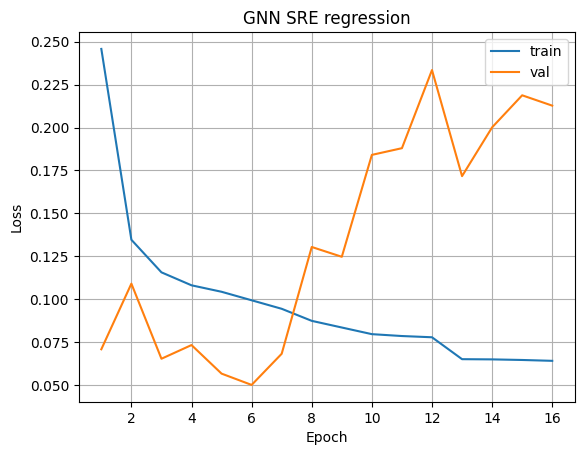

2026-05-27 15:14:34,675 - GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/random_model_gnn_per_family_2.pt
2026-05-27 15:14:34,677 - scripts.train_model - INFO - Final test loss: 0.053549
2026-05-27 15:14:34,677 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/random_model_gnn_per_family_2.pt
2026-05-27 15:15:08,840 - scripts.predictions - INFO - Found 142800 prediction files
Predicting (gnn): 100%|██████████| 8925/8925 [17:09<00:00,  8.67batch/s]
2026-05-27 15:32:28,115 - scripts.predictions - INFO - Saved 142800 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-05-27 15:32:28,319 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_random.png
2026-05-27 15:32:28,524 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_random.png


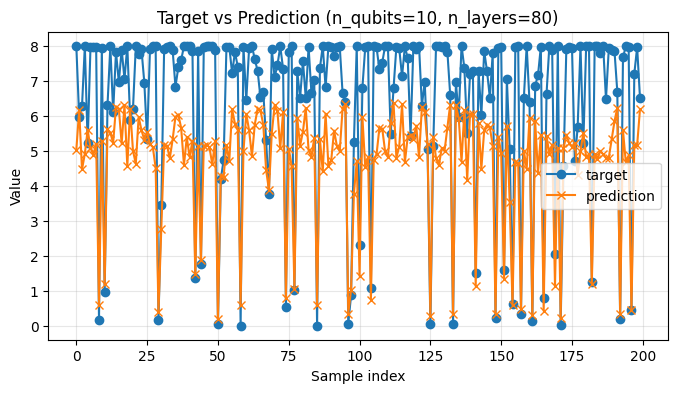

Pearson r = 0.8750


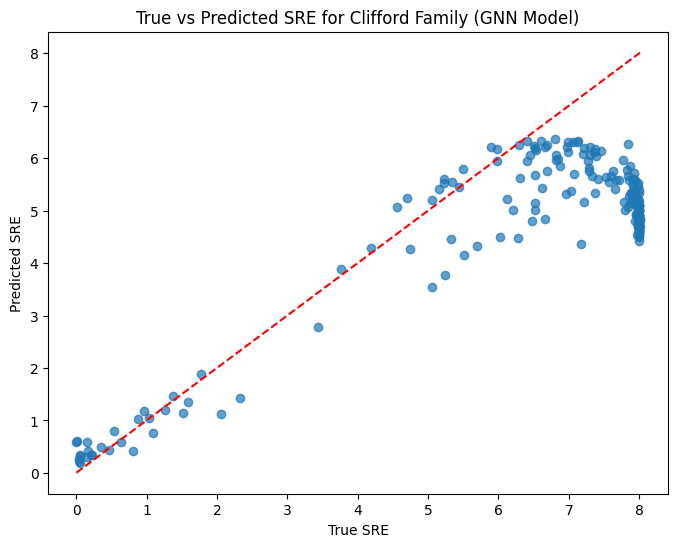

In [7]:
model_type="gnn"
epochs = 30
lr = 0.0018760928244666698
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/datasets"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}_2.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.13173830279748305,
}

train_hparams = {
    "weight_decay": 0.0003324725858640221,
    "grad_clip": 1.0289214665544766,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}


run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

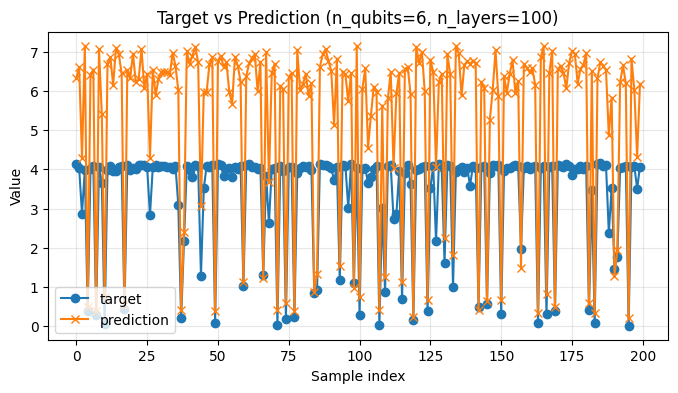

Pearson r = 0.9756


Text(0.5, 1.0, 'True vs Predicted SRE for Clifford Family (GNN Model)')

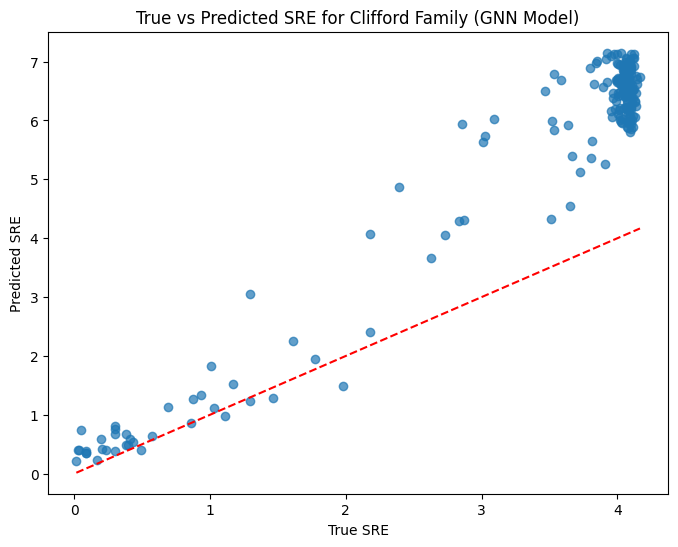

In [8]:
model_type="gnn"
epochs = 30
lr = 0.0018760928244666698
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/datasets"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}_2.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.13173830279748305,
}

train_hparams = {
    "weight_decay": 0.0003324725858640221,
    "grad_clip": 1.0289214665544766,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}


df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)
view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target",
    col_y="prediction",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target"], df["prediction"], alpha=0.7)
plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Clifford Family (GNN Model)")

2026-05-26 16:30:03,991 - GNN.training.runners - INFO - Starting training | model_type=nn | training_mode=per_family | family=random | loss_type=huber
2026-05-26 16:30:03,991 - GNN.training.runners - INFO - Training configuration done.
2026-05-26 16:30:03,992 - GNN.training.runners - INFO - Collecting data paths...
2026-05-26 16:32:43,242 - GNN.training.runners - INFO - Found 40800 data paths.
2026-05-26 16:32:43,243 - GNN.training.runners - INFO - Data paths collected.
2026-05-26 16:32:43,243 - GNN.training.runners - INFO - Building loaders and model for model_type=nn...
2026-05-26 16:33:40,227 - GNN.training.runners - INFO - Loaders and model built.
2026-05-26 16:33:40,227 - GNN.training.runners - INFO - Starting training...
2026-05-26 16:33:40,233 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/30:  81%|████████  | 740/918 [01:00<00:14, 11.89it/s, loss=1.0134, graphs=23712]

2026-05-26 16:34:40,269 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 741/918 | loss 1.013413 | elapsed 60.0s | graphs 23712


2026-05-26 16:34:54,544 - GNN.training.train - INFO - Training complete (74.3s) | running validation...


2026-05-26 16:35:02,097 - GNN.training.train - INFO - Losses | train 0.940389 | val 0.459471 | lr 1.00e-04 | time train=74.3s val=7.6s total=81.9s
2026-05-26 16:35:02,098 - GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-26 16:53:42,610 - GNN.training.train - INFO - Losses | train 0.177726 | val 0.290615 | lr 5.00e-05 | time train=70.5s val=7.1s total=77.6s
2026-05-26 16:53:42,610 - GNN.training.train - INFO - -------- EPOCH 016 --------


Epoch 16/30:  85%|████████▍ | 776/918 [01:00<00:10, 13.66it/s, loss=0.1753, graphs=24864]

2026-05-26 16:54:42,668 - GNN.training.train - INFO - [Heartbeat] Epoch 16 batch 777/918 | loss 0.175346 | elapsed 60.1s | graphs 24864


2026-05-26 16:54:53,379 - GNN.training.train - INFO - Training complete (70.8s) | running validation...


2026-05-26 16:55:00,587 - GNN.training.train - INFO - Losses | train 0.174602 | val 0.265507 | lr 5.00e-05 | time train=70.8s val=7.2s total=78.0s
2026-05-26 16:55:00,588 - GNN.training.train - INFO - Early stopping at epoch 016 | best val 0.113976 | patience exhausted (10/10)
2026-05-26 16:55:19,346 - GNN.training.runners - INFO - Training complete.


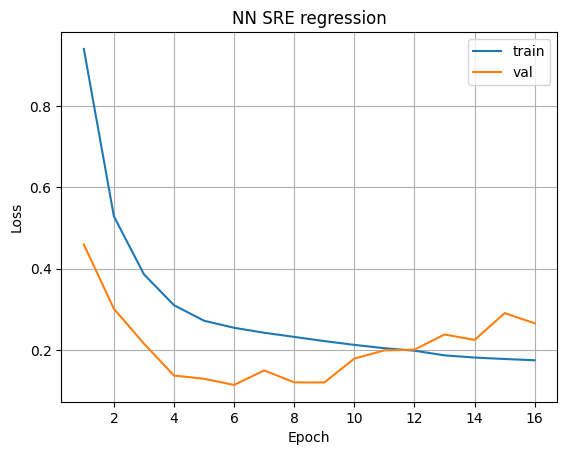

2026-05-26 16:55:19,477 - GNN.training.runners - INFO - Saved model checkpoint to ../outputs/models/random_model_nn_per_family.pt
2026-05-26 16:55:19,481 - scripts.train_model - INFO - Final test loss: 0.120889
2026-05-26 16:55:19,482 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/random_model_nn_per_family.pt
2026-05-26 16:56:03,165 - scripts.predictions - INFO - Found 142800 prediction files
Predicting (nn): 100%|██████████| 4463/4463 [04:51<00:00, 15.33batch/s]
2026-05-26 17:00:54,884 - scripts.predictions - INFO - Saved 142800 predictions to ../outputs/predictions/family/nn_predictions_random.csv
2026-05-26 17:00:55,029 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/nn_pred_layers_random.png
2026-05-26 17:00:55,205 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/nn_pred_qubits_random.png


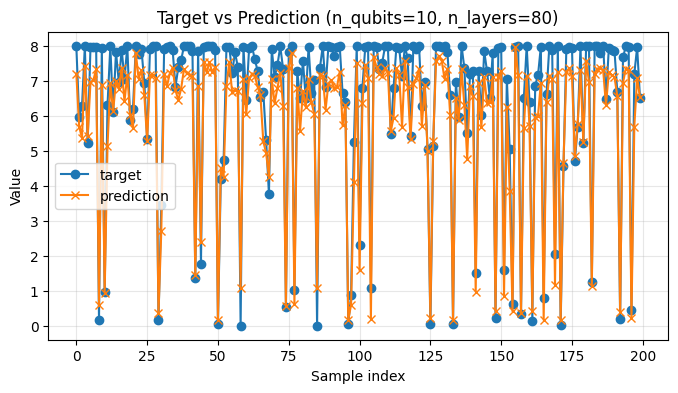

Pearson r = 0.9879


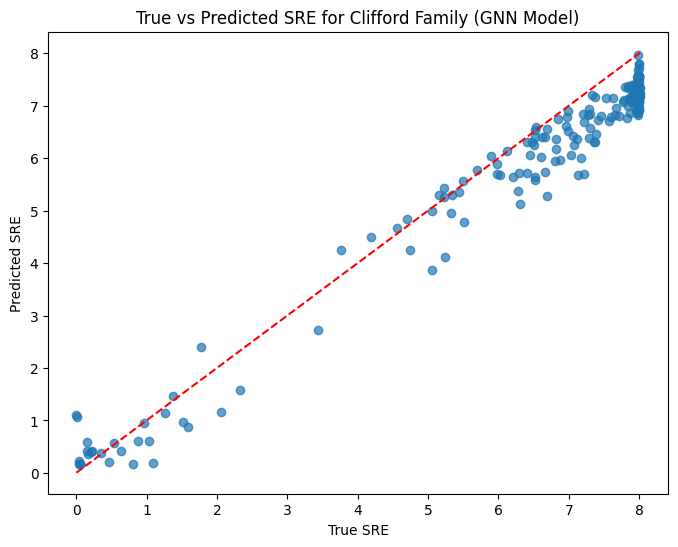

In [ ]:
model_type="nn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/datasets"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}_2.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0


default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}


run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

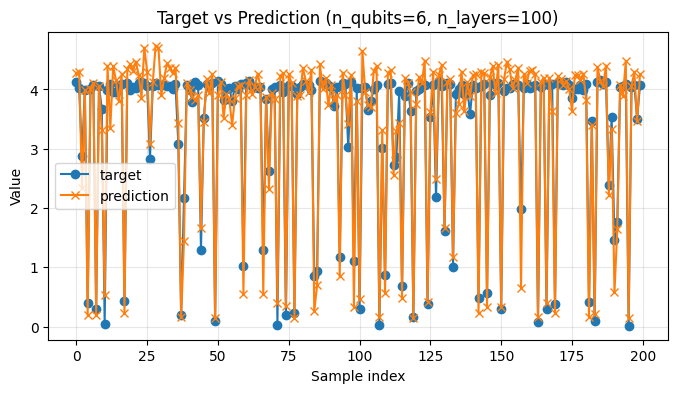

Pearson r = 0.9810


Text(0.5, 1.0, 'True vs Predicted SRE for Clifford Family (GNN Model)')

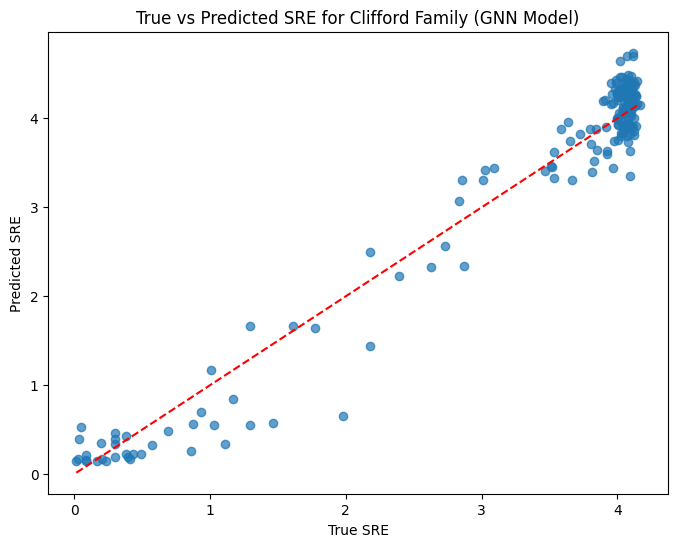

In [12]:
model_type="nn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/datasets"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100


default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}


df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)
view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target",
    col_y="prediction",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target"], df["prediction"], alpha=0.7)
plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Clifford Family (GNN Model)")

### Clifford

In [ ]:
model_type="gnn"
epochs = 30
lr = 0.0018760928244666698
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/datasets"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}_2.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.13173830279748305,
}

train_hparams = {
    "weight_decay": 0.0003324725858640221,
    "grad_clip": 1.0289214665544766,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}


run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    model_save_path=model_save_path,
)

2026-05-28 10:26:12,548 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=clifford | loss_type=huber
2026-05-28 10:26:12,553 - GNN.training.runners - INFO - Training configuration done.
2026-05-28 10:26:12,553 - GNN.training.runners - INFO - Collecting data paths...


### DATA

In [15]:
import torch
import numpy as np
from experiments.plotting import _plot_SRE_distribution

def make_dataset_loaders(
    model_type: str,
    epochs: int,
    lr: float,
    loss_type: str,
    batch_size: int,
    training_mode: str,
    family: str,
    target: str,
    data_dir: str,
    model_save_path: str,
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 10,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 600.0,
):
    cfg = TrainConfig(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        show_progress=show_progress,
        show_val_progress=show_val_progress,
        log_batch_loss_every=log_every_n_batches,
        heartbeat=heartbeat_secs,
        epoch_warning=epoch_time_warning_secs,
    )

    train_paths = collect_dataset_paths(
        data_dir,
        family=family if training_mode == "per_family" else None,
        split="target",
    )
    if not train_paths:
        raise RuntimeError("No data paths found.")
    logger.info(f"Found {len(train_paths)} data paths.")
    logger.info("Data paths collected.")

    spec = MODEL_REGISTRY[model_type]
    logger.info(f"Building loaders and model for model_type={model_type}...")

    loader_fn: Loader = spec["build_loaders"]
    returns_nodes_dim: bool = spec.get("returns_nodes_dim", False)
    if returns_nodes_dim:
        train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
    else:
        train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
        node_in_dim = global_in_dim

    return train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset


def load_sre_dataset(root: str | Path) -> pd.DataFrame:
    root = Path(root)
    rows = []

    for path in root.rglob("*.pt"):
        try:
            payload = torch.load(path, map_location="cpu", weights_only=False)
        except Exception as exc:
            print(f"Could not load {path}: {exc}")
            continue

        meta = payload.get("meta", {})

        if "sre" not in payload:
            continue

        sre = float(payload["sre"])

        if not np.isfinite(sre):
            continue

        n_qubits = int(meta.get("n_qubits", -1))
        n_layers = int(meta.get("n_layers", -1))
        family = meta.get("family", "unknown")

        row = {
            "path": str(path),
            "family": family,
            "n_qubits": n_qubits,
            "n_layers": n_layers,
            "seed": int(meta.get("seed", -1)),
            "sre": sre,
            "sre_density": sre / n_qubits if n_qubits > 0 else np.nan,
            "regime": meta.get("regime", "unknown"),
        }

        controls = meta.get("sampling_controls", {})
        for k, v in controls.items():
            row[f"ctrl_{k}"] = v

        gate_counts = payload.get("gate_counts", {})
        for k, v in gate_counts.items():
            if isinstance(v, (int, float)):
                row[f"count_{k}"] = v

        rows.append(row)

    return pd.DataFrame(rows)

In [16]:
def plot_global_sre_distribution(df: pd.DataFrame, family: str, density: bool = True):
    sub = df[df["family"] == family].copy()

    col = "sre_density" if density else "sre"
    xlabel = "SRE / n_qubits" if density else "SRE"

    values = sub[col].dropna().to_numpy()

    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=40, alpha=0.8)
    plt.xlabel(xlabel)
    plt.ylabel("Number of circuits")
    plt.title(f"{family}: global {xlabel} distribution")
    plt.tight_layout()
    plt.show()

def plot_sre_ecdf(df: pd.DataFrame, family: str, density: bool = True):
    sub = df[df["family"] == family].copy()

    col = "sre_density" if density else "sre"
    xlabel = "SRE / n_qubits" if density else "SRE"

    values = np.sort(sub[col].dropna().to_numpy())

    if len(values) == 0:
        print(f"No values for {family}")
        return

    y = np.arange(1, len(values) + 1) / len(values)

    plt.figure(figsize=(7, 4))
    plt.plot(values, y)
    plt.xlabel(xlabel)
    plt.ylabel("Cumulative fraction")
    plt.title(f"{family}: empirical CDF of {xlabel}")
    plt.tight_layout()
    plt.show()

def add_sre_bins(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    bins = [-1e-12, 1e-5, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, np.inf]
    labels = [
        "zero",
        "tiny",
        "very_low",
        "low",
        "medium_low",
        "medium",
        "high",
        "very_high",
    ]

    df["sre_bin"] = pd.cut(
        df["sre_density"],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )

    return df

def plot_sre_vs_layers(df: pd.DataFrame, family: str):
    sub = df[df["family"] == family].copy()

    plt.figure(figsize=(7, 4))
    plt.scatter(
        sub["n_layers"],
        sub["sre_density"],
        s=12,
        alpha=0.35,
    )
    plt.xlabel("Number of layers")
    plt.ylabel("SRE / n_qubits")
    plt.title(f"{family}: SRE density vs depth")
    plt.tight_layout()
    plt.show()

def plot_sre_by_qubits(df: pd.DataFrame, family: str):
    sub = df[df["family"] == family].copy()

    plt.figure(figsize=(7, 4))
    sub.boxplot(column="sre_density", by="n_qubits")
    plt.suptitle("")
    plt.title(f"{family}: SRE density by number of qubits")
    plt.xlabel("n_qubits")
    plt.ylabel("SRE / n_qubits")
    plt.tight_layout()
    plt.show()

def plot_SRE_regime(output_dir: str, family: str):
    rows = []

    for path in Path(output_dir+"/"+family).rglob("*.pt"):
        d = torch.load(path, map_location="cpu")

        meta = d["meta"]
        controls = meta.get("sampling_controls", {})
        realized = meta.get("realized_stats", {})

        row = {
            "path": str(path),
            "family": meta["family"],
            "regime": meta["regime"],
            "n_qubits": meta["n_qubits"],
            "n_layers": meta["n_layers"],
            "seed": meta["seed"],
            "sre": float(d.get("sre", np.nan)),
            "sre_density": float(d.get("sre", np.nan)) / meta["n_qubits"],
        }

        row.update({f"ctrl_{k}": v for k, v in controls.items()})
        row.update({f"real_{k}": v for k, v in realized.items()})

        rows.append(row)

    df = pd.DataFrame(rows)

    for family in df["family"].unique():
        sub = df[(df["family"] == family) & np.isfinite(df["sre_density"])]

        plt.figure()
        sub.boxplot(column="sre_density", by="regime", rot=45)
        plt.title(f"{family}: SRE density by regime")
        plt.suptitle("")
        plt.ylabel("SRE / n_qubits")
        plt.tight_layout()
        plt.show()

In [13]:
print(f"Loading dataset from {data_dir}...")
df = load_sre_dataset(data_dir)

print(df.shape)
print(df[["family", "n_qubits", "n_layers", "sre", "sre_density"]].head())

Loading dataset from ../outputs/data/datasets...
(72520, 172)
     family  n_qubits  n_layers       sre  sre_density
0  clifford        10        10  1.660150     0.166015
1  clifford        10        10  2.075187     0.207519
2  clifford        10        10  0.415037     0.041504
3  clifford        10        10  1.472523     0.147252
4  clifford        10        10  2.717635     0.271764


In [17]:
df_qubits = df.copy()

In [19]:
train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "random", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-26 16:12:57,457 - __main__ - INFO - Found 40800 data paths.
2026-05-26 16:12:57,458 - __main__ - INFO - Data paths collected.
2026-05-26 16:12:57,459 - __main__ - INFO - Building loaders and model for model_type=gnn...


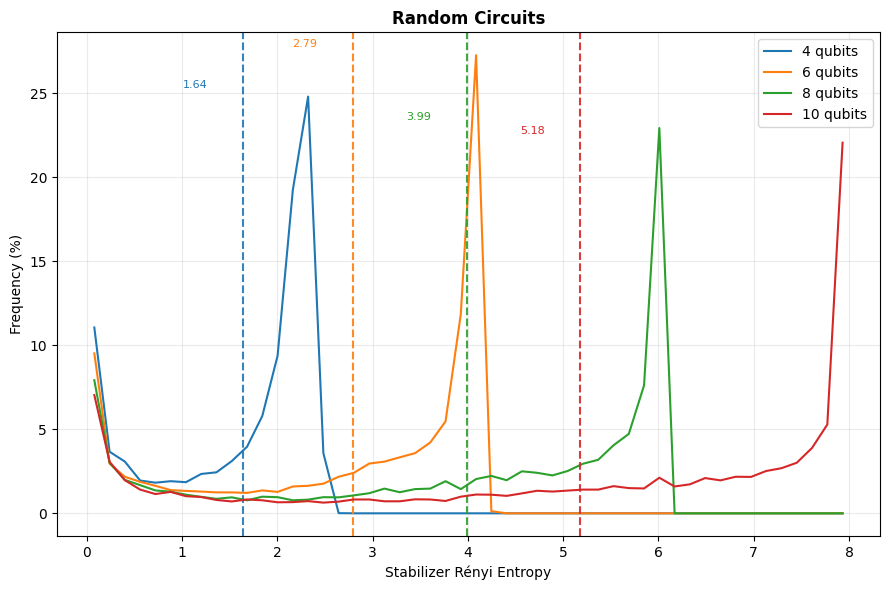

<Figure size 640x480 with 0 Axes>

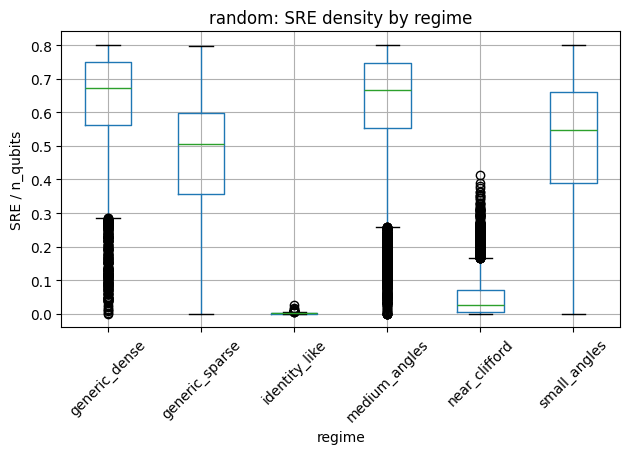

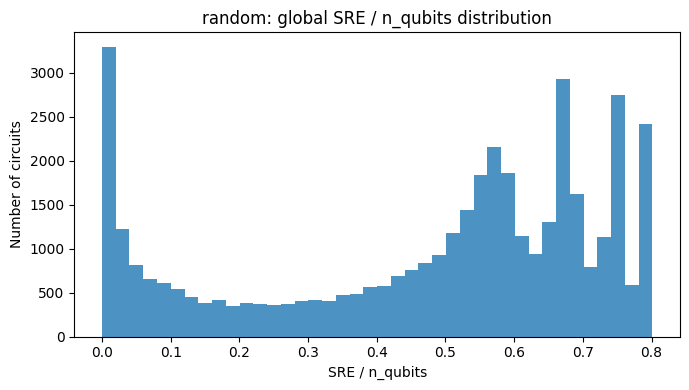

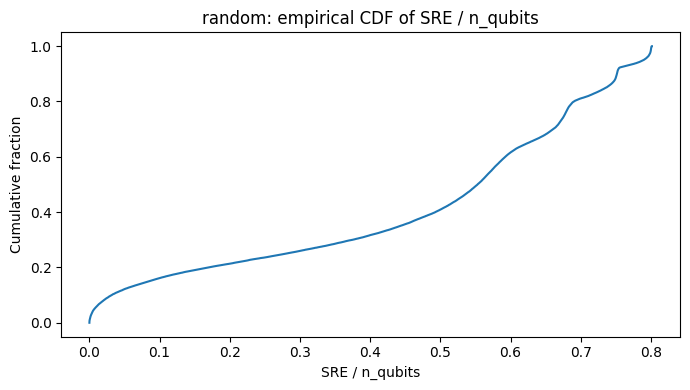

In [20]:
_plot_SRE_distribution(base_dataset, bins=50, title="Random Circuits")
plot_SRE_regime(data_dir, "random")

plot_global_sre_distribution(df_qubits, "random", density=True)
plot_sre_ecdf(df_qubits, "random", density=True)